<a href="https://colab.research.google.com/github/20skidddddddd/2434745_BibushanBahadurSingh/blob/main/2434745_BibushanBahadurSingh_Code_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 Final Assessment – Part II Vision Task
## Multi-Class Traffic Sign Classification using CNN

### 1. Introduction
### 2. Dataset Loading and Inspection
### 3. Data Understanding, Analysis, Visualization, and Cleaning
### 4. Data Preprocessing and Augmentation
### 5. Baseline CNN Model
### 6. Deeper CNN with Regularization
### 7. Experimentation and Comparative Analysis
#### 7.1 Baseline vs Deeper Model Performance
#### 7.2 Optimizer Analysis: Adam vs SGD
#### 7.3 Ablation Study
#### 7.4 Challenges and Observations
### 8. Transfer Learning with a Pretrained Model
### 9. Final Results and Discussion
### 10. Conclusion

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = "/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/dataset/Traffic_Sign-20260417T071809Z-3-001.zip"
print("ZIP exists:", os.path.exists(zip_path))

ZIP exists: True


In [ ]:
import zipfile

extract_path = "/content/traffic_sign_data"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")
print("Top-level contents:", os.listdir(extract_path))

Extraction completed.
Top-level contents: ['Traffic_Sign']


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root)
    if len(dirs) > 0:
        print(" Subfolders:", dirs[:10])
    if len(files) > 0:
        print(" Files:", files[:5])
    print("-" * 60)

/content/traffic_sign_data
 Subfolders: ['Traffic_Sign']
------------------------------------------------------------
/content/traffic_sign_data/Traffic_Sign
 Subfolders: ['Train', 'Test']
 Files: ['Dataset Description-5.txt']
------------------------------------------------------------
/content/traffic_sign_data/Traffic_Sign/Train
 Subfolders: ['Instructions', 'OverSpeed', 'No Passing', 'Caution']
------------------------------------------------------------
/content/traffic_sign_data/Traffic_Sign/Train/Instructions
 Files: ['00034_00003_00013.png', '00034_00001_00017.png', '00035_00009_00017.png', '00033_00003_00024.png', '00034_00007_00019.png']
------------------------------------------------------------
/content/traffic_sign_data/Traffic_Sign/Train/OverSpeed
 Files: ['00005_00041_00012.png', '00005_00005_00016.png', '00004_00024_00013.png', '00003_00000_00015.png', '00003_00024_00013.png']
------------------------------------------------------------
/content/traffic_sign_data/Traff

In [ ]:
base_path = "/content/traffic_sign_data/Traffic_Sign"
train_path = os.path.join(base_path, "Train")
test_path = os.path.join(base_path, "Test")

print("Train path exists:", os.path.exists(train_path))
print("Test path exists:", os.path.exists(test_path))
print("Train classes:", os.listdir(train_path))

Train path exists: True
Test path exists: True
Train classes: ['Instructions', 'OverSpeed', 'No Passing', 'Caution']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import shutil
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2

In [ ]:
class_counts = {}

for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    if os.path.isdir(class_folder):
        image_files = [f for f in os.listdir(class_folder) if os.path.isfile(os.path.join(class_folder, f))]
        class_counts[class_name] = len(image_files)

class_counts_df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Image_Count'])
class_counts_df = class_counts_df.sort_values(by='Class')
class_counts_df

,Class,Image_Count
3,Caution,2429
0,Instructions,2848
2,No Passing,5369
1,OverSpeed,5249


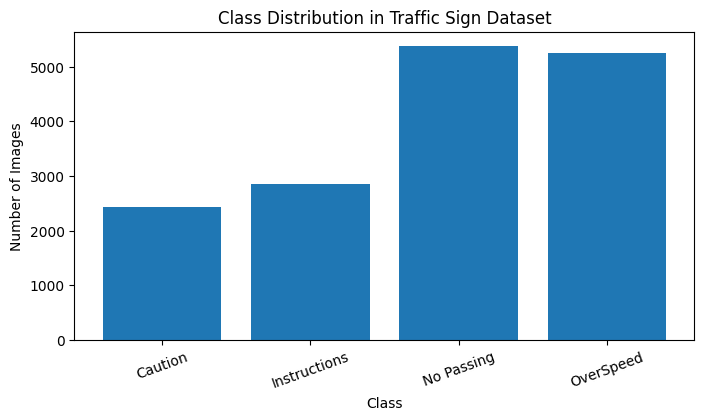

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(class_counts_df['Class'], class_counts_df['Image_Count'])
plt.title("Class Distribution in Traffic Sign Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/class_distribution.png', bbox_inches='tight')
plt.show()

The dataset contains four traffic sign classes. The class distribution is examined before model development to identify whether the dataset is balanced or imbalanced across categories.

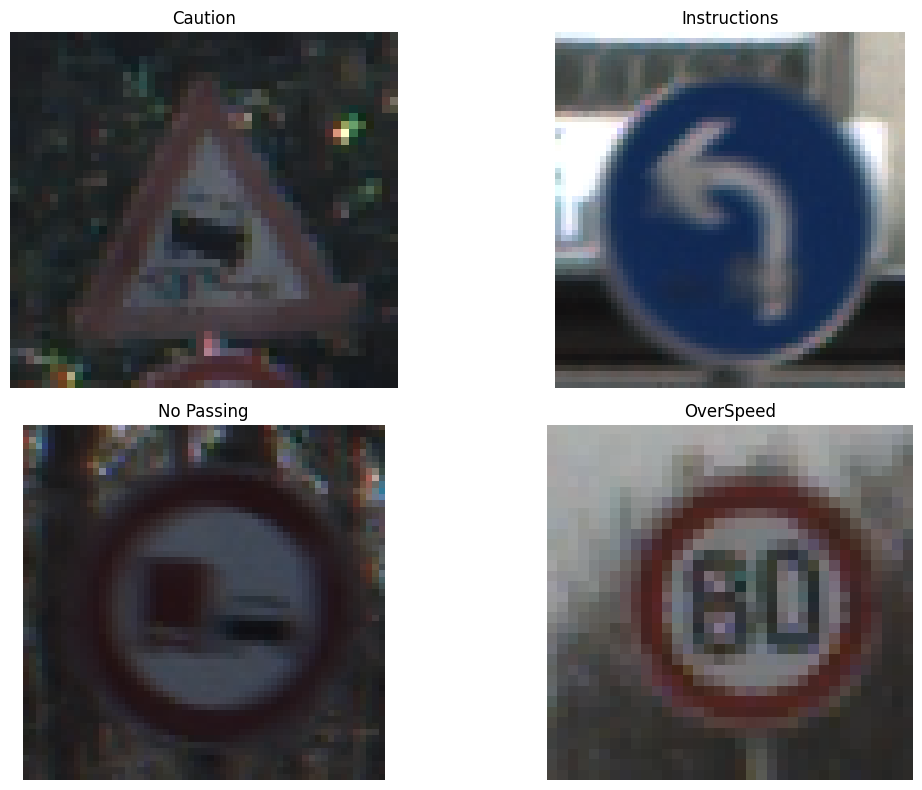

In [ ]:
classes = sorted(os.listdir(train_path))

plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):
    class_folder = os.path.join(train_path, class_name)
    sample_image_name = os.listdir(class_folder)[0]
    sample_image_path = os.path.join(class_folder, sample_image_name)

    img = Image.open(sample_image_path)

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/sample_images.png', bbox_inches='tight')
plt.show()

In [ ]:
image_sizes = []

for class_name in classes:
    class_folder = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_folder)[:200]:  # sample first 200 from each class
        img_path = os.path.join(class_folder, img_name)
        try:
            with Image.open(img_path) as img:
                image_sizes.append(img.size)
        except:
            pass

image_sizes_df = pd.DataFrame(image_sizes, columns=['Width', 'Height'])
image_sizes_df.describe()

,Width,Height
count,798.000000,798.000000
mean,49.659148,48.779449
std,23.018821,21.497955
min,25.000000,25.000000
25%,34.000000,34.000000
50%,43.000000,43.000000
75%,57.000000,56.000000
max,189.000000,169.000000


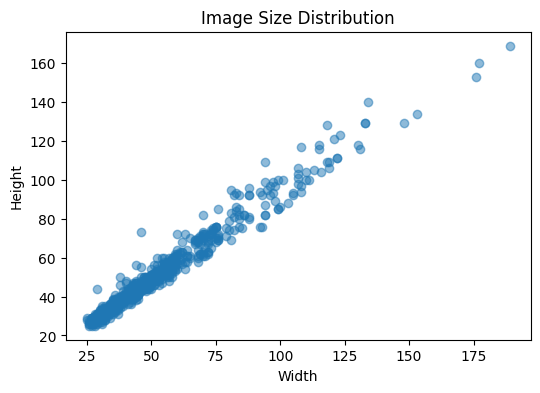

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(image_sizes_df['Width'], image_sizes_df['Height'], alpha=0.5)
plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/image_size_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
corrupted_files = []

for class_name in classes:
    class_folder = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except:
            corrupted_files.append(img_path)

print("Total corrupted files found:", len(corrupted_files))
corrupted_files[:10]

Total corrupted files found: 28


['/content/traffic_sign_data/Traffic_Sign/Train/Caution/00018_00023_00007.png',
 '/content/traffic_sign_data/Traffic_Sign/Train/Caution/00022_00001_00001.png',
 '/content/traffic_sign_data/Traffic_Sign/Train/Caution/00022_00000_00011.png',
 '/content/traffic_sign_data/Traffic_Sign/Train/Caution/00018_00031_00023.png',
 '/content/traffic_sign_data/Traffic_Sign/Train/Caution/00018_00031_00016.png',
 '/content/traffic_sign_data/Traffic_Sign/Train/Caution/00023_00009_00008.png',
 '/content/traffic_sign_data/Traffic_Sign/Train/Caution/00022_00012_00010.png',
 '/content/traffic_sign_data/Traffic_Sign/Train/Instructions/00035_00003_00001.png',
 '/content/traffic_sign_data/Traffic_Sign/Train/Instructions/00035_00019_00013.png',
 '/content/traffic_sign_data/Traffic_Sign/Train/Instructions/00028_00007_00009.png']

In [ ]:
for file_path in corrupted_files:
    if os.path.exists(file_path):
        os.remove(file_path)

print("Corrupted files removed.")

Corrupted files removed.


In [ ]:
clean_class_counts = {}

for class_name in classes:
    class_folder = os.path.join(train_path, class_name)
    image_files = [f for f in os.listdir(class_folder) if os.path.isfile(os.path.join(class_folder, f))]
    clean_class_counts[class_name] = len(image_files)

clean_class_counts_df = pd.DataFrame(list(clean_class_counts.items()), columns=['Class', 'Usable_Image_Count'])
clean_class_counts_df = clean_class_counts_df.sort_values(by='Class')
clean_class_counts_df

,Class,Usable_Image_Count
0,Caution,2422
1,Instructions,2841
2,No Passing,5362
3,OverSpeed,5242


During dataset inspection, corrupted image files were identified and removed. This cleaning step was necessary to prevent training interruptions and ensure that only valid images were used in model development.

In [ ]:
all_image_paths = []
all_labels = []

for class_name in classes:
    class_folder = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        all_image_paths.append(img_path)
        all_labels.append(class_name)

data_df = pd.DataFrame({
    'filepath': all_image_paths,
    'label': all_labels
})

print("Total usable images:", len(data_df))
data_df.head()

Total usable images: 15867


,filepath,label
0,/content/traffic_sign_data/Traffic_Sign/Train/...,Caution
1,/content/traffic_sign_data/Traffic_Sign/Train/...,Caution
2,/content/traffic_sign_data/Traffic_Sign/Train/...,Caution
3,/content/traffic_sign_data/Traffic_Sign/Train/...,Caution
4,/content/traffic_sign_data/Traffic_Sign/Train/...,Caution


In [ ]:
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=42,
    stratify=data_df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 11106
Validation size: 2380
Test size: 2381


In [ ]:
print("Train class distribution:\n", train_df['label'].value_counts(normalize=True))
print("\nValidation class distribution:\n", val_df['label'].value_counts(normalize=True))
print("\nTest class distribution:\n", test_df['label'].value_counts(normalize=True))

Train class distribution:
 label
No Passing      0.337925
OverSpeed       0.330362
Instructions    0.179092
Caution         0.152620
Name: proportion, dtype: float64

Validation class distribution:
 label
No Passing      0.337815
OverSpeed       0.330252
Instructions    0.178992
Caution         0.152941
Name: proportion, dtype: float64

Test class distribution:
 label
No Passing      0.338093
OverSpeed       0.330533
Instructions    0.178916
Caution         0.152457
Name: proportion, dtype: float64


In [ ]:
img_height = 64
img_width = 64
batch_size = 32
num_classes = len(classes)

print("Classes:", classes)
print("Number of classes:", num_classes)

Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Number of classes: 4


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 11106 validated image filenames belonging to 4 classes.
Found 2380 validated image filenames belonging to 4 classes.
Found 2381 validated image filenames belonging to 4 classes.


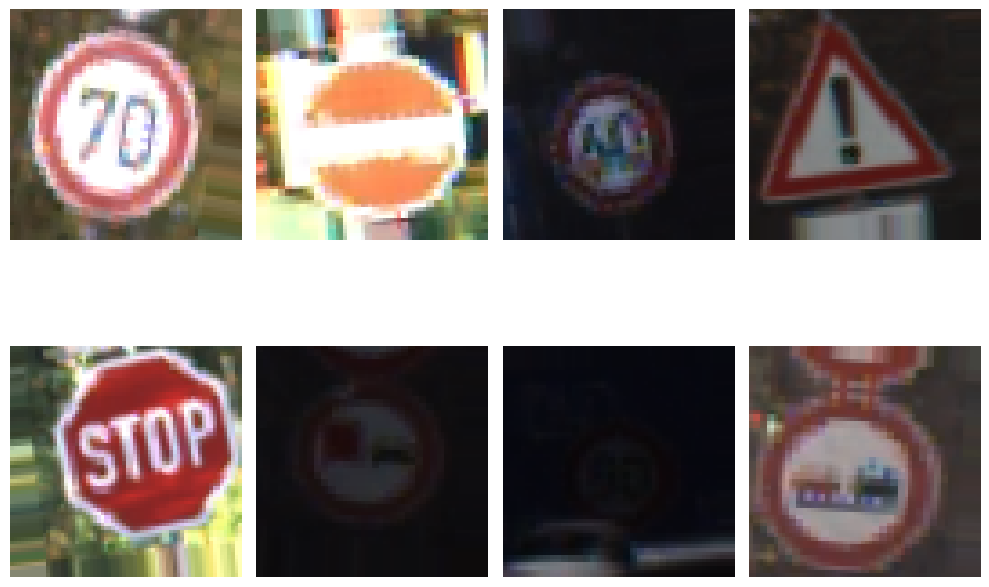

In [ ]:
sample_batch, sample_labels = next(train_generator)

plt.figure(figsize=(10,8))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(sample_batch[i])
    plt.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/augmented_samples.png', bbox_inches='tight')
plt.show()

### 5. Baseline CNN Model

In [ ]:
baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,564 (5.01 MB)

 Trainable params: 1,314,564 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

The baseline CNN model was designed with three convolutional layers, each followed by max-pooling, in accordance with the assignment requirement. After feature extraction, the network uses three fully connected layers before the final softmax output layer for multi-class classification.

In [ ]:
early_stopping_baseline = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
start_time_baseline = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping_baseline],
    verbose=1
)

baseline_training_time = time.time() - start_time_baseline
print("Baseline model training time (seconds):", round(baseline_training_time, 2))

Epoch 1/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 37s 89ms/step - accuracy: 0.8322 - loss: 0.4225 - val_accuracy: 0.9739 - val_loss: 0.0824
Epoch 2/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9697 - loss: 0.0917 - val_accuracy: 0.9958 - val_loss: 0.0154
Epoch 3/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.9892 - loss: 0.0368 - val_accuracy: 0.9803 - val_loss: 0.0514
Epoch 4/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.9908 - loss: 0.0307 - val_accuracy: 0.9912 - val_loss: 0.0267
Epoch 5/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.9909 - loss: 0.0294 - val_accuracy: 0.9887 - val_loss: 0.0316
Baseline model training time (seconds): 125.3


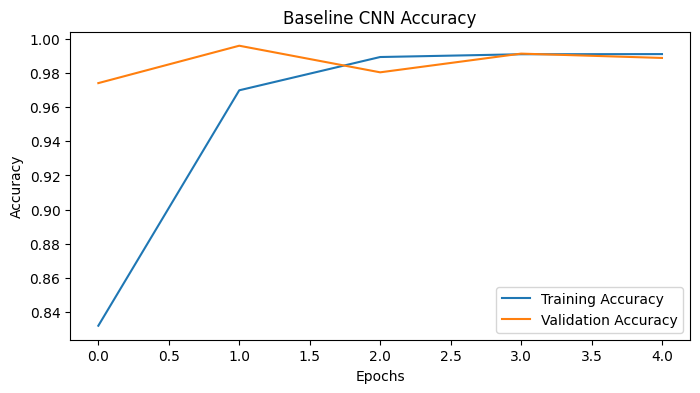

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_accuracy.png', bbox_inches='tight')
plt.show()

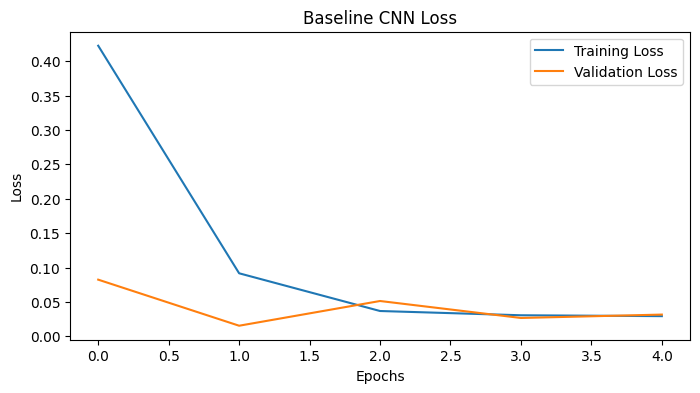

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_loss.png', bbox_inches='tight')
plt.show()

In [ ]:
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(test_generator, verbose=0)

print("Baseline Test Loss:", round(baseline_test_loss, 4))
print("Baseline Test Accuracy:", round(baseline_test_accuracy, 4))

Baseline Test Loss: 0.0164
Baseline Test Accuracy: 0.9958


In [ ]:
y_pred_baseline_prob = baseline_model.predict(test_generator)
y_pred_baseline = np.argmax(y_pred_baseline_prob, axis=1)

y_true_baseline = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Class labels:", class_labels)

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Class labels: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


In [ ]:
cm_baseline = confusion_matrix(y_true_baseline, y_pred_baseline)

print("Confusion Matrix for Baseline CNN:")
print(cm_baseline)

Confusion Matrix for Baseline CNN:
[[361   0   1   1]
 [  5 418   0   3]
 [  0   0 805   0]
 [  0   0   0 787]]


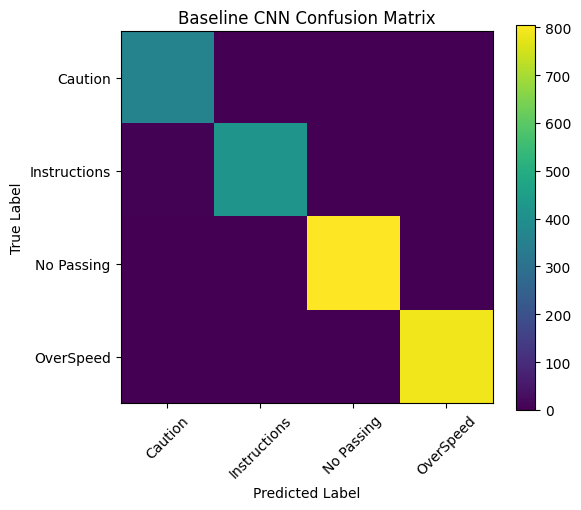

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(cm_baseline, interpolation='nearest')
plt.title("Baseline CNN Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
print("Classification Report for Baseline CNN:\n")
print(classification_report(y_true_baseline, y_pred_baseline, target_names=class_labels))

Classification Report for Baseline CNN:

              precision    recall  f1-score   support

     Caution       0.99      0.99      0.99       363
Instructions       1.00      0.98      0.99       426
  No Passing       1.00      1.00      1.00       805
   OverSpeed       0.99      1.00      1.00       787

    accuracy                           1.00      2381
   macro avg       1.00      0.99      0.99      2381
weighted avg       1.00      1.00      1.00      2381



In [ ]:
baseline_report = classification_report(y_true_baseline, y_pred_baseline, target_names=class_labels, output_dict=True)

baseline_precision = baseline_report['weighted avg']['precision']
baseline_recall = baseline_report['weighted avg']['recall']
baseline_f1 = baseline_report['weighted avg']['f1-score']

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step


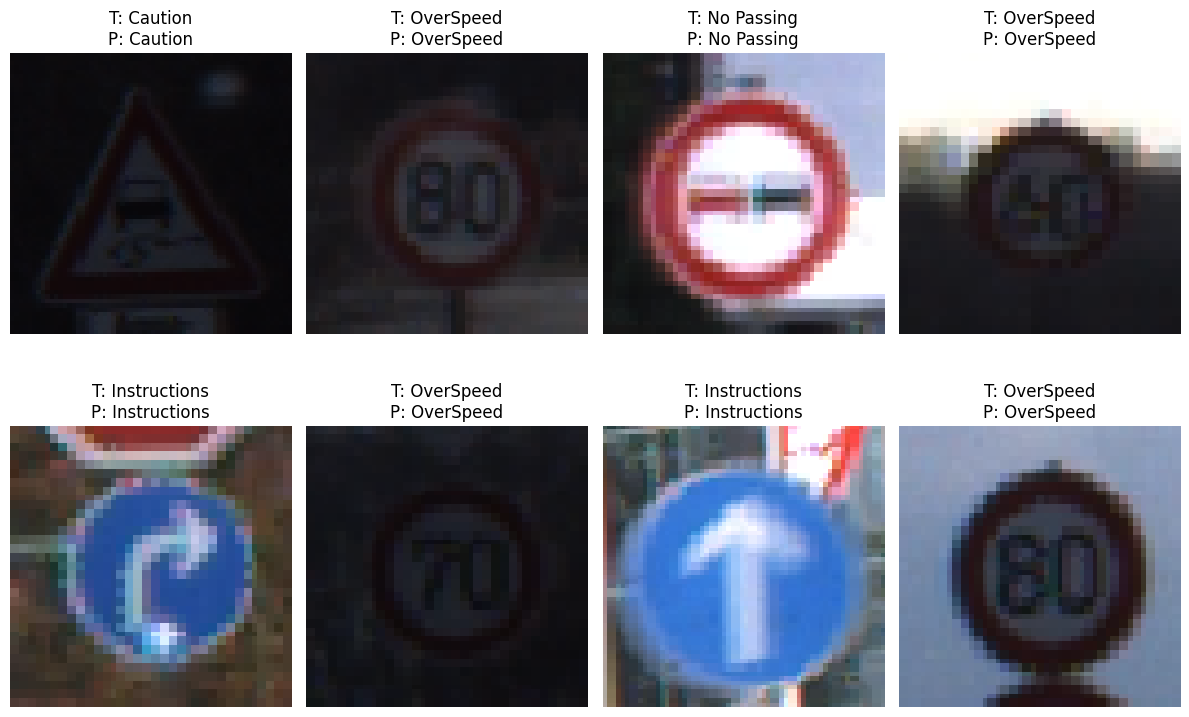

In [ ]:
sample_test_batch, sample_test_labels = next(test_generator)

sample_preds = baseline_model.predict(sample_test_batch)
sample_pred_classes = np.argmax(sample_preds, axis=1)
sample_true_classes = np.argmax(sample_test_labels, axis=1)

plt.figure(figsize=(12,8))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(sample_test_batch[i])
    plt.title(f"T: {class_labels[sample_true_classes[i]]}\nP: {class_labels[sample_pred_classes[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_sample_predictions.png', bbox_inches='tight')
plt.show()

The baseline CNN provides the first reference point for evaluating performance on the traffic sign dataset. Its results will later be compared with a deeper regularized architecture and a transfer learning model to determine whether more advanced approaches improve classification performance.

### 6. Deeper CNN with Regularization

In [ ]:
deeper_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 3,243,844 (12.37 MB)

 Trainable params: 3,242,372 (12.37 MB)

 Non-trainable params: 1,472 (5.75 KB)

The deeper CNN architecture was developed by increasing the number of convolutional layers and filters compared to the baseline model. Batch normalization and dropout were introduced as regularization techniques to improve training stability and reduce overfitting.

In [ ]:
early_stopping_deeper = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
start_time_deeper = time.time()

history_deeper = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping_deeper],
    verbose=1
)

deeper_training_time = time.time() - start_time_deeper
print("Deeper model training time (seconds):", round(deeper_training_time, 2))

Epoch 1/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 43s 90ms/step - accuracy: 0.7690 - loss: 0.6562 - val_accuracy: 0.8130 - val_loss: 0.4978
Epoch 2/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.9654 - loss: 0.1010 - val_accuracy: 0.9752 - val_loss: 0.0732
Epoch 3/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.9880 - loss: 0.0423 - val_accuracy: 0.9916 - val_loss: 0.0254
Epoch 4/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.9846 - loss: 0.0586 - val_accuracy: 0.9929 - val_loss: 0.0205
Epoch 5/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9930 - loss: 0.0248 - val_accuracy: 0.9992 - val_loss: 0.0034
Epoch 6/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.9913 - loss: 0.0357 - val_accuracy: 0.9761 - val_loss: 0.0652
Epoch 7/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9862 - loss: 0.0473 - val_accuracy: 0.9966 - val_loss: 0.0202
Epoch 8/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.9930 - loss: 0.0306 - 

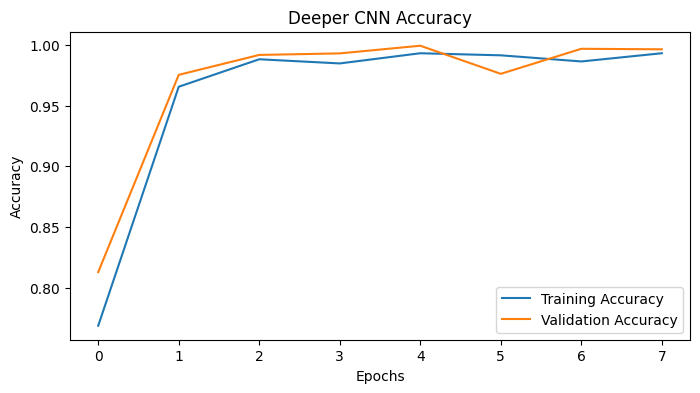

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history_deeper.history['accuracy'], label='Training Accuracy')
plt.plot(history_deeper.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deeper CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/deeper_accuracy.png', bbox_inches='tight')
plt.show()

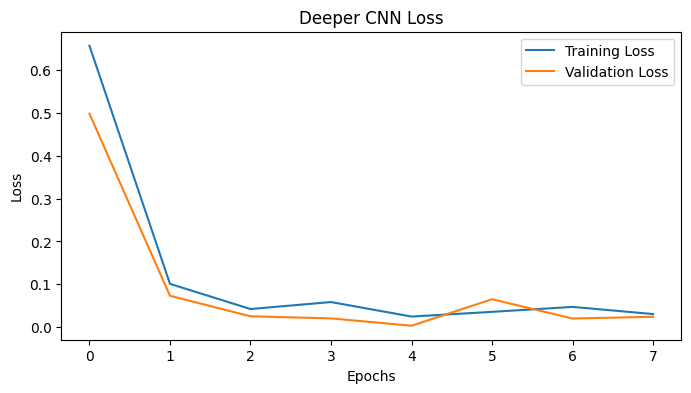

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history_deeper.history['loss'], label='Training Loss')
plt.plot(history_deeper.history['val_loss'], label='Validation Loss')
plt.title('Deeper CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/deeper_loss.png', bbox_inches='tight')
plt.show()

In [ ]:
deeper_test_loss, deeper_test_accuracy = deeper_model.evaluate(test_generator, verbose=0)

print("Deeper Model Test Loss:", round(deeper_test_loss, 4))
print("Deeper Model Test Accuracy:", round(deeper_test_accuracy, 4))

Deeper Model Test Loss: 0.0025
Deeper Model Test Accuracy: 0.9992


In [ ]:
y_pred_deeper_prob = deeper_model.predict(test_generator)
y_pred_deeper = np.argmax(y_pred_deeper_prob, axis=1)

y_true_deeper = test_generator.classes

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step


In [ ]:
cm_deeper = confusion_matrix(y_true_deeper, y_pred_deeper)

print("Confusion Matrix for Deeper CNN:")
print(cm_deeper)

Confusion Matrix for Deeper CNN:
[[363   0   0   0]
 [  0 426   0   0]
 [  0   0 803   2]
 [  0   0   0 787]]


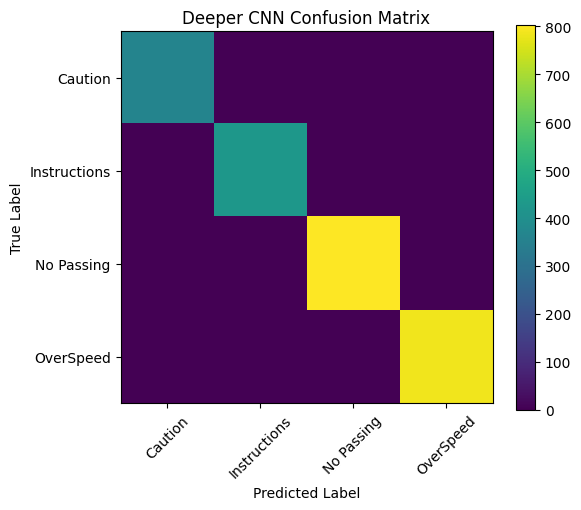

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(cm_deeper, interpolation='nearest')
plt.title("Deeper CNN Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/deeper_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
print("Classification Report for Deeper CNN:\n")
print(classification_report(y_true_deeper, y_pred_deeper, target_names=class_labels))

Classification Report for Deeper CNN:

              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       363
Instructions       1.00      1.00      1.00       426
  No Passing       1.00      1.00      1.00       805
   OverSpeed       1.00      1.00      1.00       787

    accuracy                           1.00      2381
   macro avg       1.00      1.00      1.00      2381
weighted avg       1.00      1.00      1.00      2381



In [ ]:
deeper_report = classification_report(y_true_deeper, y_pred_deeper, target_names=class_labels, output_dict=True)

deeper_precision = deeper_report['weighted avg']['precision']
deeper_recall = deeper_report['weighted avg']['recall']
deeper_f1 = deeper_report['weighted avg']['f1-score']

In [ ]:
vision_comparison_df = pd.DataFrame({
    'Model': ['Baseline CNN', 'Deeper CNN'],
    'Test Accuracy': [baseline_test_accuracy, deeper_test_accuracy],
    'Precision': [baseline_precision, deeper_precision],
    'Recall': [baseline_recall, deeper_recall],
    'F1-Score': [baseline_f1, deeper_f1],
    'Training Time (sec)': [baseline_training_time, deeper_training_time]
})

vision_comparison_df

,Model,Test Accuracy,Precision,Recall,F1-Score,Training Time (sec)
0,Baseline CNN,0.99580,0.995826,0.99580,0.995792,125.300311
1,Deeper CNN,0.99916,0.999162,0.99916,0.999160,203.280999


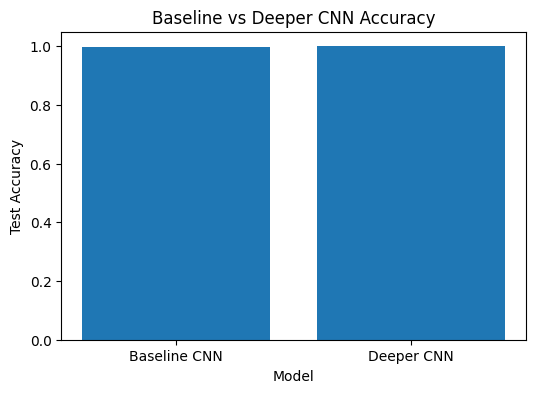

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(vision_comparison_df['Model'], vision_comparison_df['Test Accuracy'])
plt.title('Baseline vs Deeper CNN Accuracy')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_vs_deeper_accuracy.png', bbox_inches='tight')
plt.show()

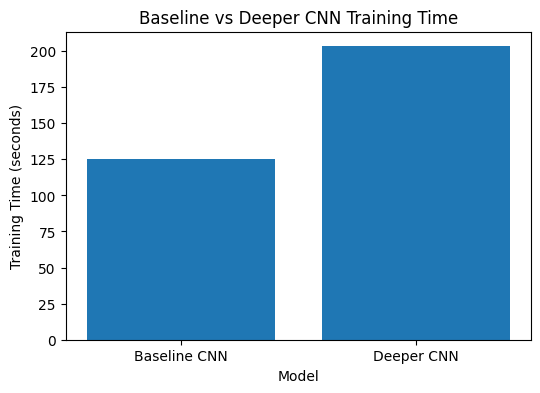

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(vision_comparison_df['Model'], vision_comparison_df['Training Time (sec)'])
plt.title('Baseline vs Deeper CNN Training Time')
plt.xlabel('Model')
plt.ylabel('Training Time (seconds)')
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_vs_deeper_time.png', bbox_inches='tight')
plt.show()

In [ ]:
deeper_model_sgd = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

deeper_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model_sgd.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 3,243,844 (12.37 MB)

 Trainable params: 3,242,372 (12.37 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
start_time_sgd = time.time()

history_deeper_sgd = deeper_model_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping_deeper],
    verbose=1
)

sgd_training_time = time.time() - start_time_sgd
print("Deeper model with SGD training time (seconds):", round(sgd_training_time, 2))

Epoch 1/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 37s 80ms/step - accuracy: 0.6809 - loss: 0.8060 - val_accuracy: 0.6101 - val_loss: 1.1345
Epoch 2/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9125 - loss: 0.2520 - val_accuracy: 0.9559 - val_loss: 0.1448
Epoch 3/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.9554 - loss: 0.1310 - val_accuracy: 0.9874 - val_loss: 0.0388
Deeper model with SGD training time (seconds): 81.76


In [ ]:
sgd_test_loss, sgd_test_accuracy = deeper_model_sgd.evaluate(test_generator, verbose=0)

print("Deeper Model with SGD Test Loss:", round(sgd_test_loss, 4))
print("Deeper Model with SGD Test Accuracy:", round(sgd_test_accuracy, 4))

Deeper Model with SGD Test Loss: 1.0819
Deeper Model with SGD Test Accuracy: 0.6153


In [ ]:
optimizer_comparison_df = pd.DataFrame({
    'Optimizer': ['Adam', 'SGD'],
    'Test Accuracy': [deeper_test_accuracy, sgd_test_accuracy],
    'Training Time (sec)': [deeper_training_time, sgd_training_time]
})

optimizer_comparison_df

,Optimizer,Test Accuracy,Training Time (sec)
0,Adam,0.999160,203.280999
1,SGD,0.615288,81.764848


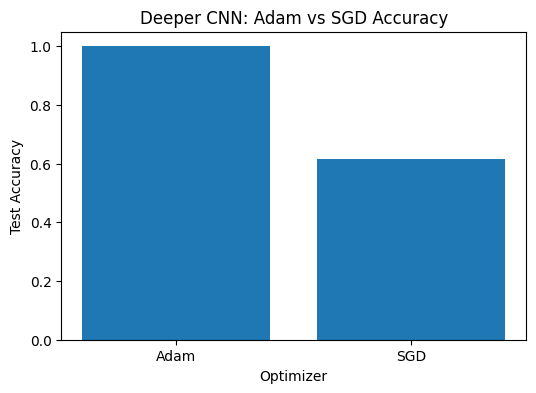

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(optimizer_comparison_df['Optimizer'], optimizer_comparison_df['Test Accuracy'])
plt.title('Deeper CNN: Adam vs SGD Accuracy')
plt.xlabel('Optimizer')
plt.ylabel('Test Accuracy')
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/adam_vs_sgd_accuracy.png', bbox_inches='tight')
plt.show()

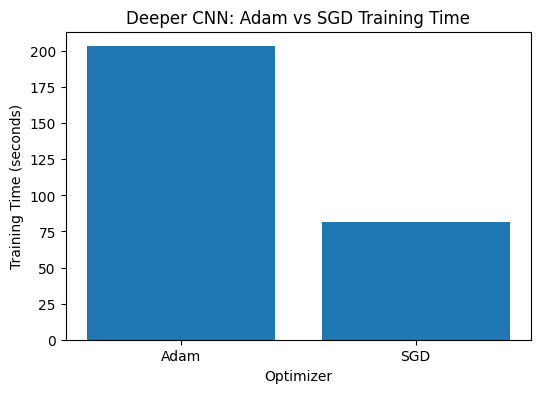

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(optimizer_comparison_df['Optimizer'], optimizer_comparison_df['Training Time (sec)'])
plt.title('Deeper CNN: Adam vs SGD Training Time')
plt.xlabel('Optimizer')
plt.ylabel('Training Time (seconds)')
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/adam_vs_sgd_time.png', bbox_inches='tight')
plt.show()

build ablation model without dropout

In [ ]:
ablation_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    Flatten(),

    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ablation_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,844 (12.37 MB)

 Trainable params: 3,242,372 (12.37 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
start_time_ablation = time.time()

history_ablation = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping_deeper],
    verbose=1
)

ablation_training_time = time.time() - start_time_ablation
print("Ablation model training time (seconds):", round(ablation_training_time, 2))

Epoch 1/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 36s 78ms/step - accuracy: 0.9128 - loss: 0.2389 - val_accuracy: 0.8235 - val_loss: 0.4596
Epoch 2/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.9874 - loss: 0.0365 - val_accuracy: 0.9895 - val_loss: 0.0541
Epoch 3/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.9914 - loss: 0.0282 - val_accuracy: 0.9929 - val_loss: 0.0175
Ablation model training time (seconds): 84.54


In [ ]:
ablation_test_loss, ablation_test_accuracy = ablation_model.evaluate(test_generator, verbose=0)

print("Ablation Model Test Loss:", round(ablation_test_loss, 4))
print("Ablation Model Test Accuracy:", round(ablation_test_accuracy, 4))

Ablation Model Test Loss: 0.4589
Ablation Model Test Accuracy: 0.8261


In [ ]:
ablation_comparison_df = pd.DataFrame({
    'Model': ['Deeper CNN (with Dropout)', 'Ablation CNN (without Dropout)'],
    'Test Accuracy': [deeper_test_accuracy, ablation_test_accuracy],
    'Training Time (sec)': [deeper_training_time, ablation_training_time]
})

ablation_comparison_df

,Model,Test Accuracy,Training Time (sec)
0,Deeper CNN (with Dropout),0.999160,203.280999
1,Ablation CNN (without Dropout),0.826123,84.541139


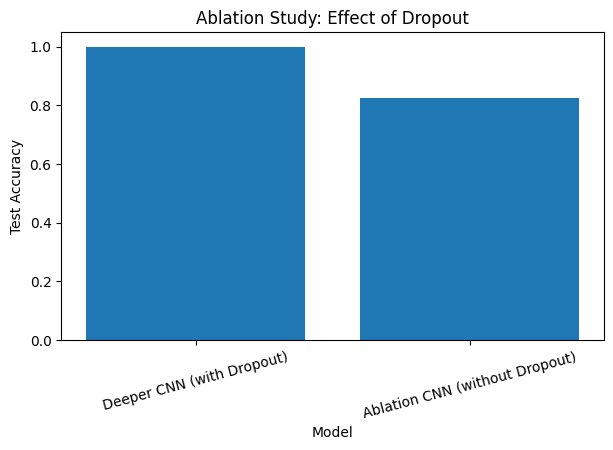

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(ablation_comparison_df['Model'], ablation_comparison_df['Test Accuracy'])
plt.title('Ablation Study: Effect of Dropout')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=15)
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/ablation_accuracy.png', bbox_inches='tight')
plt.show()

The optimizer comparison was carried out on the deeper CNN using Adam and SGD to observe differences in convergence speed, computational time, and final predictive performance.

The ablation study was performed by removing dropout from the deeper architecture. This helps evaluate whether dropout regularization improved generalization and reduced overfitting in the original deeper model.

### 8. Transfer Learning with a Pretrained Model

In [ ]:
tl_img_height = 224
tl_img_width = 224
tl_batch_size = 32

In [ ]:
train_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_datagen_tl = ImageDataGenerator(rescale=1./255)

train_generator_tl = train_datagen_tl.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=(tl_img_height, tl_img_width),
    batch_size=tl_batch_size,
    class_mode='categorical'
)

val_generator_tl = val_test_datagen_tl.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=(tl_img_height, tl_img_width),
    batch_size=tl_batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator_tl = val_test_datagen_tl.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=(tl_img_height, tl_img_width),
    batch_size=tl_batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 11106 validated image filenames belonging to 4 classes.
Found 2380 validated image filenames belonging to 4 classes.
Found 2381 validated image filenames belonging to 4 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(tl_img_height, tl_img_width, 3)
)

base_model.trainable = False

print("Base model loaded. Trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded. Trainable: False


In [ ]:
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

The transfer learning model uses MobileNetV2 pretrained on ImageNet as the convolutional feature extractor. The original top layers were removed, and a new classifier head was added to adapt the network to the four traffic sign classes.

In [ ]:
early_stopping_tl = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start_time_tl = time.time()

history_transfer = transfer_model.fit(
    train_generator_tl,
    validation_data=val_generator_tl,
    epochs=10,
    callbacks=[early_stopping_tl],
    verbose=1
)

transfer_training_time = time.time() - start_time_tl
print("Transfer learning model training time (seconds):", round(transfer_training_time, 2))

Epoch 1/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 186s 478ms/step - accuracy: 0.8955 - loss: 0.2690 - val_accuracy: 0.9525 - val_loss: 0.1269
Epoch 2/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 136s 391ms/step - accuracy: 0.9503 - loss: 0.1300 - val_accuracy: 0.9504 - val_loss: 0.1240
Epoch 3/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 142s 390ms/step - accuracy: 0.9637 - loss: 0.0957 - val_accuracy: 0.9727 - val_loss: 0.0769
Epoch 4/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 136s 391ms/step - accuracy: 0.9697 - loss: 0.0834 - val_accuracy: 0.9744 - val_loss: 0.0731
Epoch 5/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 138s 398ms/step - accuracy: 0.9714 - loss: 0.0743 - val_accuracy: 0.9718 - val_loss: 0.0733
Epoch 6/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 135s 388ms/step - accuracy: 0.9750 - loss: 0.0672 - val_accuracy: 0.9731 - val_loss: 0.0770
Epoch 7/10
348/348 ━━━━━━━━━━━━━━━━━━━━ 133s 383ms/step - accuracy: 0.9761 - loss: 0.0616 - val_accuracy: 0.9664 - val_loss: 0.0943
Transfer learning model training time (seconds): 1007.77


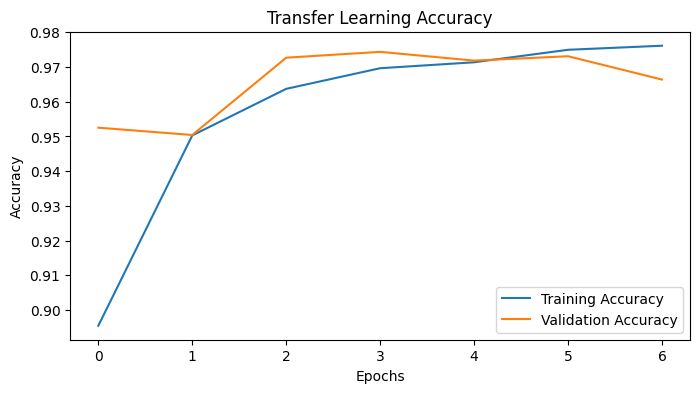

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/transfer_accuracy.png', bbox_inches='tight')
plt.show()

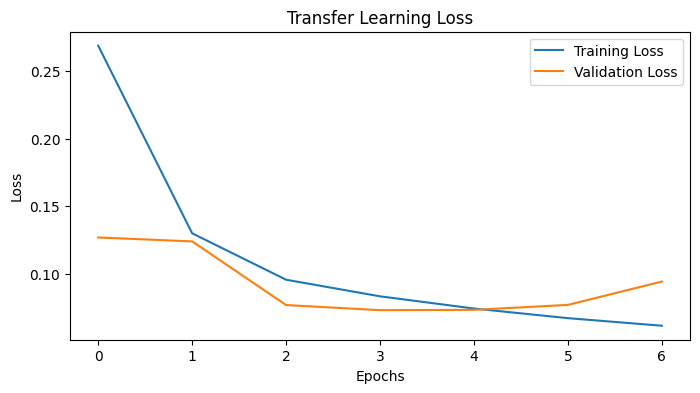

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/transfer_loss.png', bbox_inches='tight')
plt.show()

In [ ]:
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_generator_tl, verbose=0)

print("Transfer Learning Test Loss:", round(transfer_test_loss, 4))
print("Transfer Learning Test Accuracy:", round(transfer_test_accuracy, 4))

Transfer Learning Test Loss: 0.0625
Transfer Learning Test Accuracy: 0.9765


In [ ]:
y_pred_transfer_prob = transfer_model.predict(test_generator_tl)
y_pred_transfer = np.argmax(y_pred_transfer_prob, axis=1)

y_true_transfer = test_generator_tl.classes

75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 148ms/step


In [ ]:
cm_transfer = confusion_matrix(y_true_transfer, y_pred_transfer)

print("Confusion Matrix for Transfer Learning Model:")
print(cm_transfer)

Confusion Matrix for Transfer Learning Model:
[[360   3   0   0]
 [ 18 408   0   0]
 [  1   2 783  19]
 [  0   0  13 774]]


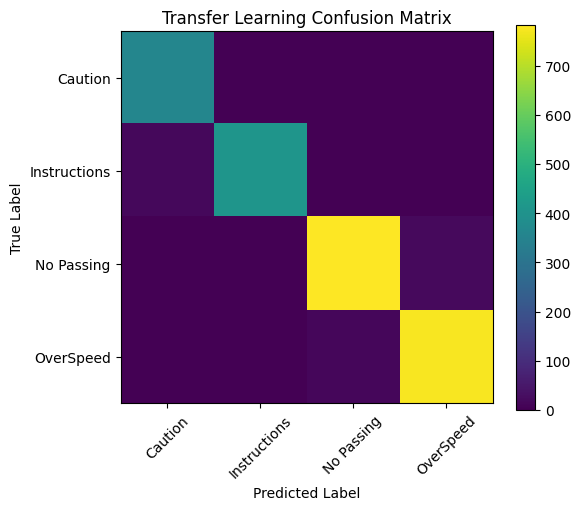

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(cm_transfer, interpolation='nearest')
plt.title("Transfer Learning Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/transfer_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
print("Classification Report for Transfer Learning Model:\n")
print(classification_report(y_true_transfer, y_pred_transfer, target_names=class_labels))

Classification Report for Transfer Learning Model:

              precision    recall  f1-score   support

     Caution       0.95      0.99      0.97       363
Instructions       0.99      0.96      0.97       426
  No Passing       0.98      0.97      0.98       805
   OverSpeed       0.98      0.98      0.98       787

    accuracy                           0.98      2381
   macro avg       0.97      0.98      0.98      2381
weighted avg       0.98      0.98      0.98      2381



In [ ]:
transfer_report = classification_report(y_true_transfer, y_pred_transfer, target_names=class_labels, output_dict=True)

transfer_precision = transfer_report['weighted avg']['precision']
transfer_recall = transfer_report['weighted avg']['recall']
transfer_f1 = transfer_report['weighted avg']['f1-score']

In [ ]:
final_vision_comparison_df = pd.DataFrame({
    'Model': [
        'Baseline CNN',
        'Deeper CNN (Adam)',
        'Deeper CNN (SGD)',
        'Ablation CNN (No Dropout)',
        'MobileNetV2 Transfer Learning'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        deeper_test_accuracy,
        sgd_test_accuracy,
        ablation_test_accuracy,
        transfer_test_accuracy
    ],
    'Precision': [
        baseline_precision,
        deeper_precision,
        np.nan,
        np.nan,
        transfer_precision
    ],
    'Recall': [
        baseline_recall,
        deeper_recall,
        np.nan,
        np.nan,
        transfer_recall
    ],
    'F1-Score': [
        baseline_f1,
        deeper_f1,
        np.nan,
        np.nan,
        transfer_f1
    ],
    'Training Time (sec)': [
        baseline_training_time,
        deeper_training_time,
        sgd_training_time,
        ablation_training_time,
        transfer_training_time
    ]
})

final_vision_comparison_df

,Model,Test Accuracy,Precision,Recall,F1-Score,Training Time (sec)
0,Baseline CNN,0.995800,0.995826,0.99580,0.995792,125.300311
1,Deeper CNN (Adam),0.999160,0.999162,0.99916,0.999160,203.280999
2,Deeper CNN (SGD),0.615288,NaN,NaN,NaN,81.764848
3,Ablation CNN (No Dropout),0.826123,NaN,NaN,NaN,84.541139
4,MobileNetV2 Transfer Learning,0.976480,0.976750,0.97648,0.976489,1007.771416


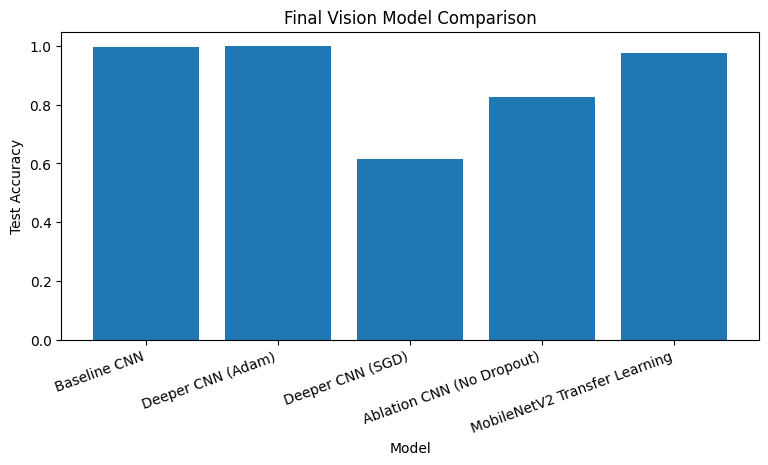

In [ ]:
plt.figure(figsize=(9,4))
plt.bar(final_vision_comparison_df['Model'], final_vision_comparison_df['Test Accuracy'])
plt.title('Final Vision Model Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=20, ha='right')
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/final_vision_comparison.png', bbox_inches='tight')
plt.show()

### 9. Final Results and Discussion

In [ ]:
vision_output_path = "/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/outputs/final_vision_comparison_results.csv"
final_vision_comparison_df.to_csv(vision_output_path, index=False)
print("Saved to:", vision_output_path)

Saved to: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/outputs/final_vision_comparison_results.csv


In [ ]:
deeper_model.save('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/outputs/best_vision_model.keras')
print("Best vision model saved successfully.")

Best vision model saved successfully.


In [ ]:
import os

output_folder = "/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/outputs"
print("Output folder exists:", os.path.exists(output_folder))
print("Files inside outputs folder:", os.listdir(output_folder))

Output folder exists: True
Files inside outputs folder: ['final_vision_comparison_results.csv', 'best_vision_model.keras']


In [ ]:
base_drive_path = "/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task"
for root, dirs, files in os.walk(base_drive_path):
    print("FOLDER:", root)
    if files:
        print("FILES:", files)
    print("-" * 60)

FOLDER: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task
------------------------------------------------------------
FOLDER: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/dataset
FILES: ['Traffic_Sign-20260417T071809Z-3-001.zip']
------------------------------------------------------------
FOLDER: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/notebook
FILES: ['2434745_BibushanBahadurSingh.ipynb']
------------------------------------------------------------
FOLDER: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/outputs
FILES: ['final_vision_comparison_results.csv', 'best_vision_model.keras']
------------------------------------------------------------
FOLDER: /content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures
FILES: ['class_distribution.png', 'sample_images.png', 'image_size_distribution.png', 'augmented_samples.png', 'baseline_accuracy.png', 'baseline_loss.png', 'baseline_confusion_matrix.png', 'baseline_sample_prediction

### 10. Conclusion


The vision experiments compared a baseline CNN, a deeper regularized CNN, optimizer variants, an ablation model, and a transfer learning approach based on MobileNetV2. The deeper model showed the impact of increased architectural depth and regularization, while the optimizer comparison highlighted differences in convergence and performance. The ablation study demonstrated the contribution of dropout to generalization. Finally, transfer learning provided a strong practical benchmark using pretrained visual features.

Overall, the results indicate that more advanced architectures can significantly improve traffic sign classification performance when supported by appropriate preprocessing, augmentation, and regularization.